In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly

set_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

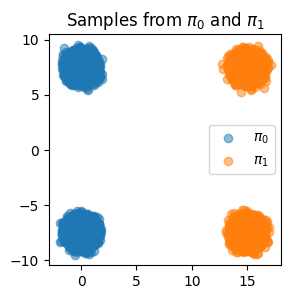

In [2]:
# generate distributions

from rectified_flow.datasets.toy_gmm import TwoPointGMM

n_samples = 50000
pi_0 = TwoPointGMM(x=0.0, y=7.5, std=0.5, device=device)
pi_1 = TwoPointGMM(x=15.0, y=7.5, std=0.5, device=device)
D0 = pi_0.sample([n_samples])
D1, labels = pi_1.sample_with_labels([n_samples])
labels.tolist()

plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(D0[:, 0].cpu(), D0[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(D1[:, 0].cpu(), D1[:, 1].cpu(), alpha=0.5, label=r'$\pi_1$')
plt.legend()

In [ ]:
# 1 - rectified flow
x_0 = pi_0.sample([500])
x_0_upper = x_0.clone()
x_0_upper[:, 1] = torch.abs(x_0_upper[:, 1])
x_0_lower = x_0.clone()
x_0_lower[:, 1] = -torch.abs(x_0_lower[:, 1])

x_1_upper = pi_1.sample([500])
x_1_lower = pi_1.sample([500])

interp_upper = []
interp_lower = []

for t in np.linspace(0, 1, 100):
    x_t_uppper = (1 - t) * x_0_upper + t * x_1_upper
    x_t_lower = (1 - t) * x_0_lower + t * x_1_lower
    interp_upper.append(x_t_uppper)
    interp_lower.append(x_t_lower)

visualize_2d_trajectories_plotly(
    trajectories_dict={
        "upper": interp_upper,
        "lower": interp_lower,
    },
    D1_gt_samples=torch.cat([x_1_upper, x_1_lower], dim=0),
    num_trajectories=100,
    title="Straight Interpolation",
)


In [ ]:
# Learning a rectified flow velocity with mlp
from rectified_flow.models.toy_mlp import MLPVelocity

model = MLPVelocity(2, hidden_sizes=[128, 128, 128]).to(device)
rectified_flow = RectifiedFlow(
    data_shape=(2,),
    velocity_field=model,
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 1024

losses = []

for step in range(5000):
    optimizer.zero_grad()
    idx = torch.randperm(n_samples)[:batch_size]
    x_0 = D0[idx].to(device)
    x_1 = D1[idx].to(device)

    loss = rectified_flow.get_loss(x_0, x_1)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 1000 == 0:
        print(f"Epoch {step}, Loss: {loss.item()}")

plt.plot(losses)

In [ ]:
from rectified_flow.samplers import EulerSampler
from rectified_flow.utils import visualize_2d_trajectories_plotly

euler_sampler_1rf_unconditional = EulerSampler(
    rectified_flow=rectified_flow,
    num_steps=100,
)

traj_upper = euler_sampler_1rf_unconditional.sample_loop(x_0=x_0_upper).trajectories
traj_lower = euler_sampler_1rf_unconditional.sample_loop(x_0=x_0_lower).trajectories

visualize_2d_trajectories_plotly(
    trajectories_dict={"upper": traj_upper, "lower": traj_lower},
    D1_gt_samples=D1[:1000],
    num_trajectories=200,
    title="Unconditional 1-Rectified Flow",
)


In [ ]:
# learning a conditional rectified flow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned

model_cond = MLPVelocityConditioned(2, hidden_sizes=[128, 128, 128]).to(device)

rectified_flow_cond = RectifiedFlow(
    data_shape=(2,),
    velocity_field=model_cond,
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

optimizer = torch.optim.Adam(model_cond.parameters(), lr=1e-3)
batch_size = 1024

losses = []

for step in range(5000):
    optimizer.zero_grad()
    idx = torch.randperm(n_samples)[:batch_size]
    x_0 = D0[idx]
    x_1, cond = D1[idx], labels[idx]

    x_0 = x_0.to(device)
    x_1 = x_1.to(device)
    cond = torch.tensor(cond).to(device)

    loss = rectified_flow_cond.get_loss(x_0, x_1, labels=cond)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 1000 == 0:
        print(f"Epoch {step}, Loss: {loss.item()}")

plt.plot(losses)

In [ ]:
from rectified_flow.samplers import EulerSampler
from rectified_flow.utils import visualize_2d_trajectories_plotly

euler_sampler_1rf_conditional = EulerSampler(
    rectified_flow=rectified_flow_cond,
    num_steps=1,
    num_samples=500,
)

cond = torch.zeros((500,), device=device)
euler_sampler_1rf_conditional.sample_loop(seed=0, labels=cond)

visualize_2d_trajectories_plotly(
    {"1rf cond": euler_sampler_1rf_conditional.trajectories},
    D1[:1000],
    num_trajectories=200,
    title="Conditional 1-Rectified Flow",
)

In [ ]:
# reflow for 2-rectified flow
Z_0 = rectified_flow.sample_source_distribution(batch_size=50000)

Z_1 = euler_sampler_1rf_unconditional.sample_loop(x_0=Z_0, num_steps=1000).trajectories[-1]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 1024

losses = []

for step in range(5000):
    optimizer.zero_grad()
    idx = torch.randperm(n_samples)[:batch_size]
    x_0 = Z_0[idx]
    x_1 = Z_1[idx]

    x_0 = x_0.to(device)
    x_1 = x_1.to(device)

    loss = rectified_flow.get_loss(x_0, x_1)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 1000 == 0:
        print(f"Epoch {step}, Loss: {loss.item()}")

plt.plot(losses)

In [ ]:
euler_sampler_2rf = EulerSampler(
    rectified_flow=rectified_flow,
    num_samples=1000,
)

euler_sampler_2rf.sample_loop(num_steps=100, seed=0)

visualize_2d_trajectories_plotly(
    {"2rf": euler_sampler_2rf.trajectories},
    D1[:1000],
    num_trajectories=200,
    title="Reflow Trajectories, 100-step",
)

In [ ]:
euler_sampler_2rf.sample_loop(num_steps=1, seed=0)

visualize_2d_trajectories_plotly(
    {"2rf one-step": euler_sampler_2rf.trajectories},
    D1[:1000],
    num_trajectories=200,
    title="Reflow Trajectories, 1-step",
)